## 1 Exploration & Nettoyage des données

Cette première étape consiste à explorer, comprendre et fiabiliser le jeu de données avant de passer à l'entraînement des modèles de régression.

Les principales opérations réalisées sont :
- Chargement du dataset
- Vérification de la structure des données
- Analyse des valeurs manquantes
- Suppression des doublons
- Imputation des valeurs manquantes
- Correction des types de données
- Analyse exploratoire des variables
- Détection et traitement des valeurs aberrantes
- Préparation des variables pour la modélisation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.1 Chargement du jeu de données

Le dataset est chargé à l'aide de Pandas. Il contient les informations nécessaires pour prédire le prix de vente d'une voiture d'occasion.

In [80]:
df = pd.read_csv("../data/car-price.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007.0,135000,50000.0,Petrol,Individual,Manual,NaN
2,Hyundai Verna 1.6 SX,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner


## 2.2 Vérification de la structure des données

Avant toute transformation, nous vérifions les types des colonnes, les dimensions du dataset et la présence de valeurs manquantes.

Cette vérification permet d'identifier les variables numériques et catégoriques et de déterminer les traitements nécessaires.

In [81]:
print("===== TYPES DES COLONNES =====")
print(df.dtypes)

print("\n===== DIMENSIONS =====")
print(df.shape)

print("\n===== VALEURS MANQUANTES =====")
print(df.isnull().sum())

===== TYPES DES COLONNES =====
name                 str
year             float64
selling_price      int64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object

===== DIMENSIONS =====
(4340, 8)

===== VALEURS MANQUANTES =====
name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64


## 2.3 Détection et suppression des doublons

Les doublons peuvent introduire plusieurs fois la même observation dans le dataset et ainsi fausser l'analyse et l'apprentissage du modèle.

Nous identifions d'abord le nombre de doublons, puis nous les supprimons.

In [82]:
duplicate_count = df.duplicated().sum()

print(f"Nombre de doublons : {duplicate_count}")

df = df.drop_duplicates()

print(f"Dimensions après suppression : {df.shape}")

Nombre de doublons : 635
Dimensions après suppression : (3705, 8)


## 2.4 Traitement des valeurs manquantes

Les valeurs manquantes sont traitées selon la nature de chaque variable.

Pour les variables numériques, nous utilisons des informations disponibles dans des groupes similaires afin de conserver au maximum la structure du dataset.

Pour les variables catégoriques, nous utilisons la valeur la plus fréquente (mode) dans des groupes de voitures similaires.

Cette stratégie permet d'éviter la suppression des lignes contenant des valeurs manquantes.

In [83]:
print("===== VALEURS MANQUANTES AVANT IMPUTATION =====")
print(df.isnull().sum())

===== VALEURS MANQUANTES AVANT IMPUTATION =====
name               0
year              43
selling_price      0
km_driven        170
fuel              84
seller_type       65
transmission       0
owner             86
dtype: int64


### Imputation de l'année

Pour les voitures dont l'année est manquante, nous utilisons d'abord la moyenne de l'année des voitures ayant le même nom.

Si aucune information n'est disponible pour ce groupe, une deuxième stratégie est appliquée en utilisant l'intervalle de kilométrage comme groupe de référence.

In [84]:
df["year"] = df["year"].fillna(
    df.groupby("name")["year"]
      .transform("mean")
      .round()
)

df["year"] = df["year"].fillna(
    df.groupby(
        pd.cut(
            df["km_driven"],
            bins=range(
                0,
                int(df["km_driven"].max()) + 50000,
                50000
            )
        )
    )["year"]
    .transform("mean")
    .round()
)

### Imputation du kilométrage

Pour `km_driven`, la médiane est utilisée car elle est moins sensible aux valeurs extrêmes.

Nous utilisons d'abord les voitures ayant le même nom et la même année. Si aucune valeur n'est disponible, nous utilisons la médiane du kilométrage pour la même année.

In [85]:
df["km_driven"] = df["km_driven"].fillna(
    df.groupby(["name", "year"])["km_driven"]
      .transform("median")
      .round()
)

df["km_driven"] = df["km_driven"].fillna(
    df.groupby("year")["km_driven"]
      .transform("median")
      .round()
)

## 2.5 Imputation des variables catégoriques

Les variables catégoriques sont complétées avec le mode, c'est-à-dire la valeur la plus fréquente dans un groupe de voitures similaires.

L'imputation est effectuée progressivement en utilisant des groupes de plus en plus généraux lorsque l'information nécessaire n'est pas disponible.

In [87]:
# ==============================
# FUEL
# ==============================

# Même nom de voiture
df["fuel"] = df["fuel"].fillna(
    df.groupby("name")["fuel"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

# Même année
df["fuel"] = df["fuel"].fillna(
    df.groupby("year")["fuel"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)


# ==============================
# SELLER TYPE
# ==============================

# Même owner + même année
df["seller_type"] = df["seller_type"].fillna(
    df.groupby(["owner", "year"])["seller_type"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

# Même nom + même année
df["seller_type"] = df["seller_type"].fillna(
    df.groupby(["name", "year"])["seller_type"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)


# ==============================
# OWNER
# ==============================

# Même seller_type + même année
df["owner"] = df["owner"].fillna(
    df.groupby(["seller_type", "year"])["owner"]
      .transform(
          lambda x: x.dropna().mode()[0]
          if not x.dropna().mode().empty
          else None
      )
)

## 2.6 Vérification après traitement

Après l'imputation, nous vérifions à nouveau les valeurs manquantes afin de confirmer que les colonnes concernées ont été correctement complétées.

In [88]:
print("===== VALEURS MANQUANTES APRÈS IMPUTATION =====")
print(df.isnull().sum())

===== VALEURS MANQUANTES APRÈS IMPUTATION =====
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


## 2.7 Correction des types de données

Après le traitement des valeurs manquantes, les variables numériques `year` et `km_driven` sont converties en entiers afin d'obtenir une structure de données cohérente.

In [89]:
df["year"] = df["year"].astype(int)
df["km_driven"] = df["km_driven"].astype(int)

print(df.dtypes)

name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object


In [90]:
print("Dimensions finales après nettoyage :", df.shape)

Dimensions finales après nettoyage : (3705, 8)


## 2.8 Analyse statistique descriptive

Nous réalisons une première analyse statistique afin de comprendre la distribution des variables numériques.

Les principales statistiques étudiées sont :
- moyenne
- médiane
- écart-type
- minimum
- maximum
- quartiles

In [ ]:
df.describe()

,year,selling_price,km_driven
count,3705.000000,3.705000e+03,3705.000000
mean,2012.975978,4.753006e+05,68731.426991
std,4.234706,5.095973e+05,47081.951291
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,35299.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [99]:
print("===== FREQUENCES =====")

for col in ["fuel", "seller_type", "transmission", "owner"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

===== FREQUENCES =====

--- fuel ---
fuel
Diesel      2116
Petrol      2077
CNG           38
LPG           22
Electric       1
Name: count, dtype: int64

--- seller_type ---
seller_type
Individual          3198
Dealer               976
Trustmark Dealer     101
Name: count, dtype: int64

--- transmission ---
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

--- owner ---
owner
First Owner             2771
Second Owner            1084
Third Owner              302
Fourth & Above Owner      80
Test Drive Car            17
Name: count, dtype: int64


## 2.9 Distribution du kilométrage et du prix

Les histogrammes permettent d'observer la distribution de `km_driven` et `selling_price` et d'identifier visuellement une éventuelle asymétrie ou présence de valeurs extrêmes.

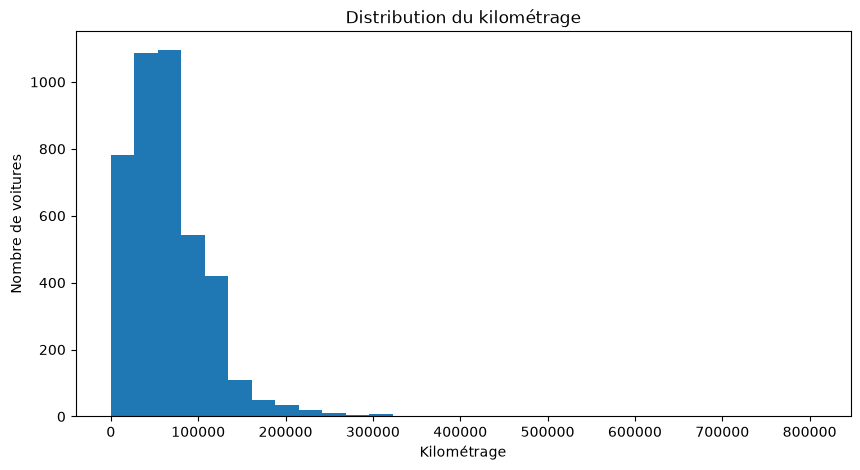

In [100]:
plt.figure(figsize=(10, 5))
plt.hist(df["km_driven"], bins=30)
plt.xlabel("Kilométrage")
plt.ylabel("Nombre de voitures")
plt.title("Distribution du kilométrage")
plt.show()

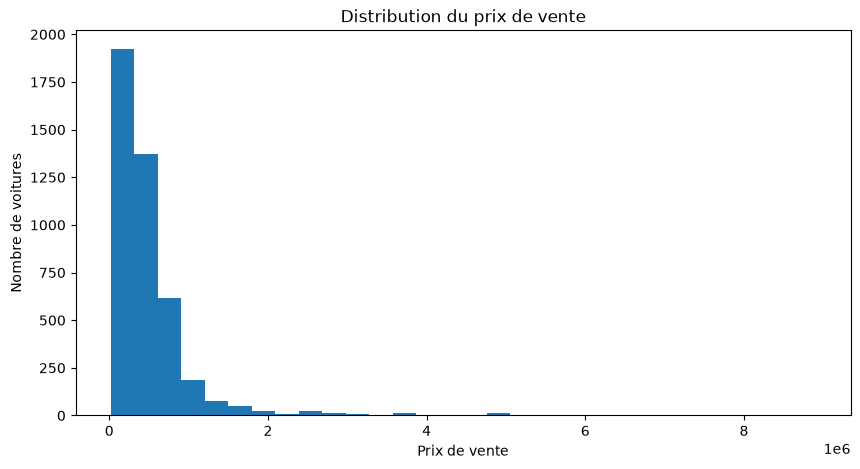

In [101]:
plt.figure(figsize=(10, 5))
plt.hist(df["selling_price"], bins=30)
plt.xlabel("Prix de vente")
plt.ylabel("Nombre de voitures")
plt.title("Distribution du prix de vente")
plt.show()

## 2.10 Matrice de corrélation

La matrice de corrélation permet d'étudier les relations entre les variables numériques et notamment l'influence potentielle de l'année et du kilométrage sur le prix de vente.

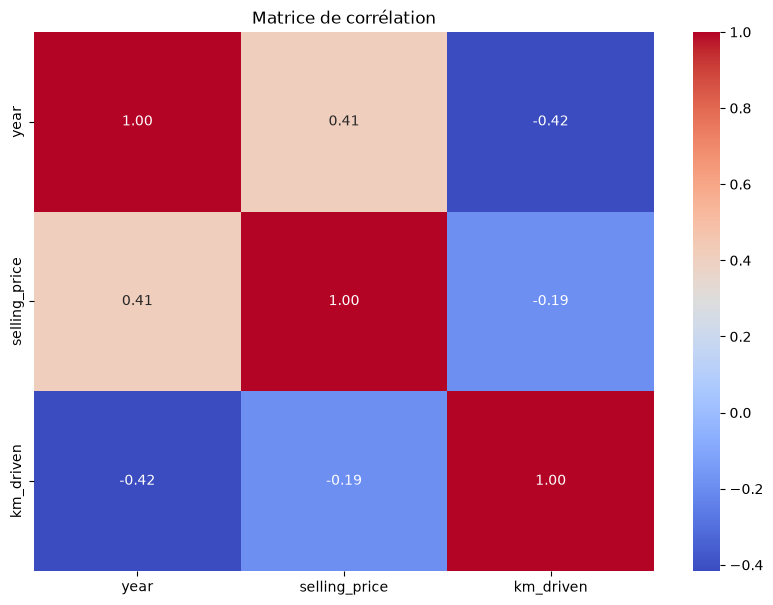

In [102]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.show()

## 2.11 Impact de l'année et du kilométrage sur le prix

Nous visualisons la relation entre `year`, `km_driven` et `selling_price` afin d'identifier les tendances présentes dans les données.

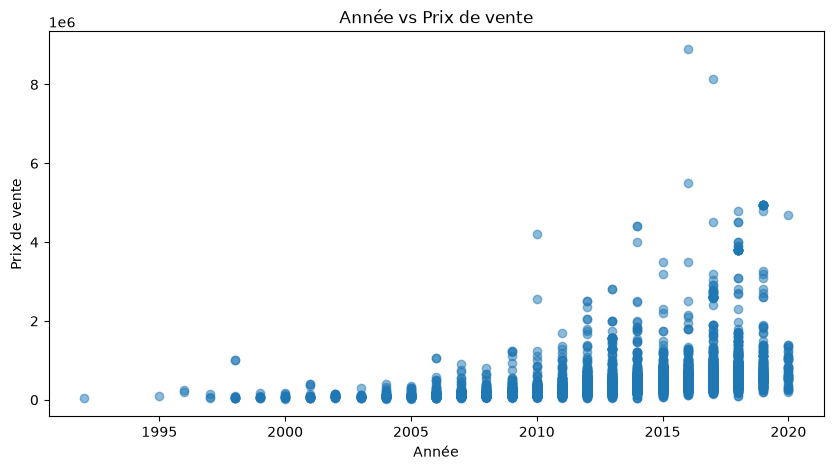

In [103]:
plt.figure(figsize=(10, 5))
plt.scatter(df["year"], df["selling_price"], alpha=0.5)
plt.xlabel("Année")
plt.ylabel("Prix de vente")
plt.title("Année vs Prix de vente")
plt.show()

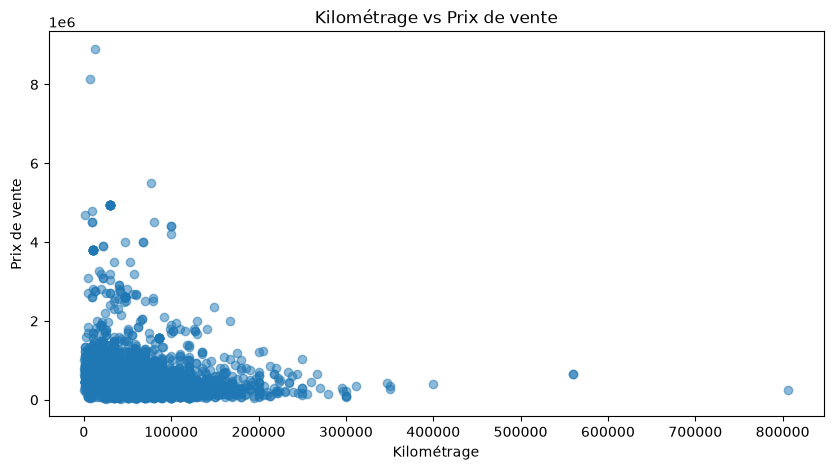

In [104]:
plt.figure(figsize=(10, 5))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.5)
plt.xlabel("Kilométrage")
plt.ylabel("Prix de vente")
plt.title("Kilométrage vs Prix de vente")
plt.show()

## 2.12 Détection des valeurs aberrantes

Les valeurs aberrantes peuvent influencer fortement les performances des modèles de régression.

Nous utilisons des boîtes à moustaches pour identifier visuellement les observations extrêmes dans les variables `selling_price`, `km_driven` et `year`.

/tmp/ipykernel_7897/2300168915.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


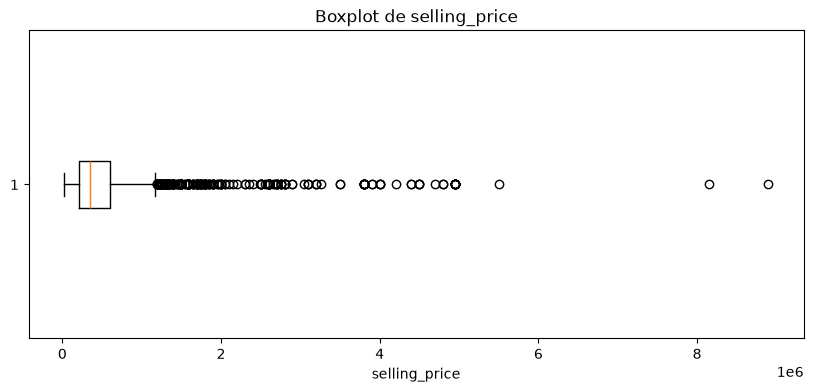

/tmp/ipykernel_7897/2300168915.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


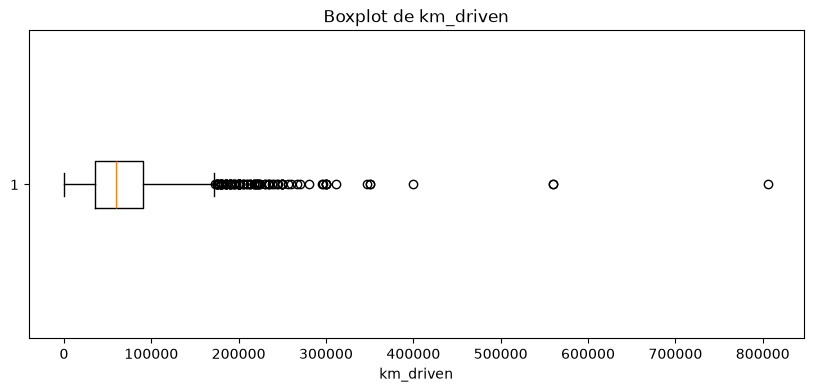

/tmp/ipykernel_7897/2300168915.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


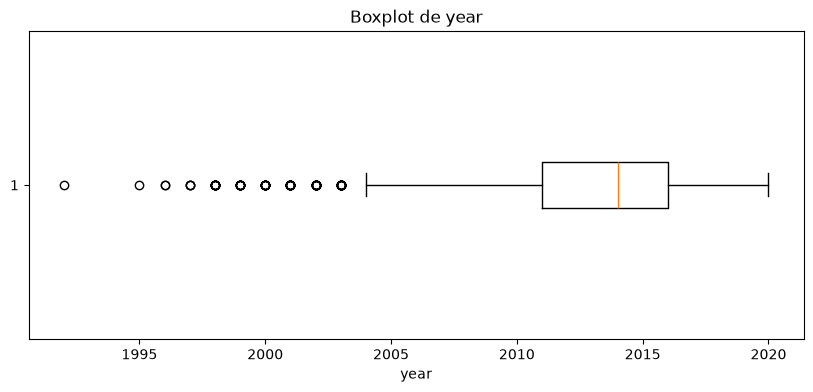

In [105]:
columns = ["selling_price", "km_driven", "year"]

for col in columns:
    plt.figure(figsize=(10, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot de {col}")
    plt.show()